# 📊 EDA E-Commerce — Analisis Eksplorasi Dataset Smartphone
> **Dataset:** `ecommerce_clean_merged.csv` — gabungan data listing smartphone dari Shopee, Lazada, dan Tokopedia  
> **Tujuan:** Memahami distribusi harga, penjualan, rating, dan perilaku pasar per brand dan per platform  
> **Author:** Raissa | Multi-Platform Big Data Analysis

## 1. Import Library & Load Data

In [1]:
pip install pandas matplotlib seaborn numpy jupyter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 59.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# setting visual
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

### Load Dataset

In [3]:
df = pd.read_csv("ecommerce_clean_merged.csv")

In [4]:
df.head()

,Produk,Harga_Produk,Produk_Terjual,Lokasi_Toko,E-Commerce,Brand_Ekstrak,Segmen_Harga,Valid_Terjual
0,devilmimi realme C71 8GB+16GB / 128GB Handphon...,2139000.0,568.0,surabaya (kota),Shopee,realme,Upper-Mid,True
1,Samsung Galaxy A07 4/64GB - Black,1599000.0,10000.0,surabaya (kota),Shopee,samsung,Mid-Range,True
2,Samsung Galaxy A16 8/128GB - Black,2759000.0,10000.0,jakarta utara (kota),Shopee,samsung,Upper-Mid,True
3,HP IPHONE 14 128GB - Garansi Resmi Indonesia,9165000.0,13.0,surabaya (kota),Shopee,apple,Premium,True
4,Infinix Hot 60i 6/128GB - Up to 12GB Extended ...,1799000.0,10000.0,jakarta utara (kota),Shopee,infinix,Mid-Range,True


### Informasi Struktur Data

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4433 entries, 0 to 4432
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Produk          4433 non-null   object 
 1   Harga_Produk    4433 non-null   float64
 2   Produk_Terjual  4433 non-null   float64
 3   Lokasi_Toko     4433 non-null   object 
 4   E-Commerce      4433 non-null   object 
 5   Brand_Ekstrak   4433 non-null   object 
 6   Segmen_Harga    4433 non-null   object 
 7   Valid_Terjual   4433 non-null   bool   
dtypes: bool(1), float64(2), object(5)
memory usage: 246.9+ KB


In [6]:
df.isnull().sum()

,0
Produk,0
Harga_Produk,0
Produk_Terjual,0
Lokasi_Toko,0
E-Commerce,0
Brand_Ekstrak,0
Segmen_Harga,0
Valid_Terjual,0


In [7]:
df.describe()

,Harga_Produk,Produk_Terjual
count,4.433000e+03,4433.000000
mean,3.146799e+06,475.585382
std,3.739466e+06,2626.206043
min,1.000000e+05,0.000000
25%,1.245000e+06,0.000000
50%,1.899000e+06,1.000000
75%,3.599000e+06,63.000000
max,2.500000e+07,27380.000000


> **Insight:** Dataset memiliki 4.433 baris produk smartphone dari 3 marketplace setelah proses cleaning.  
> Missing value = 0, tipe data sudah sesuai hasil preprocessing.

---
## 2. Analisis per Brand

Bagian ini menganalisis distribusi harga, jumlah listing, dan penjualan berdasarkan brand smartphone.

### 2.1 Distribusi Harga per Brand
Boxplot menampilkan sebaran harga (min, Q1, median, Q3, max) untuk setiap brand.  
Brand dengan boxplot tinggi dan lebar menunjukkan variasi harga yang besar (ada varian entry-level hingga premium).

Brand_Ekstrak
samsung    818
infinix    582
xiaomi     469
other      412
oppo       375
tecno      374
vivo       347
realme     297
apple      154
poco       121
Name: count, dtype: int64


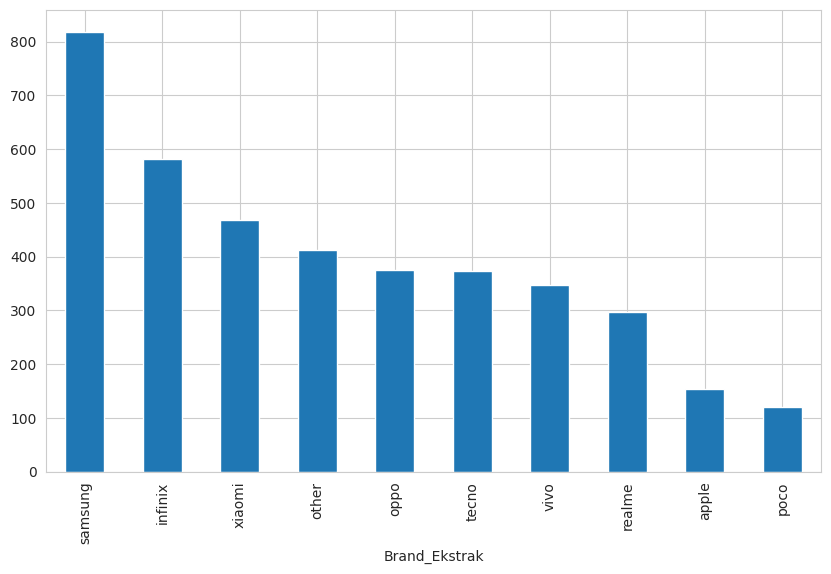

In [8]:
top_brand = df['Brand_Ekstrak'].value_counts().head(10).index

df_top = df[df['Brand_Ekstrak'].isin(top_brand)]

print(df_top['Brand_Ekstrak'].value_counts())
df_top['Brand_Ekstrak'].value_counts().plot(kind='bar')
plt.show()

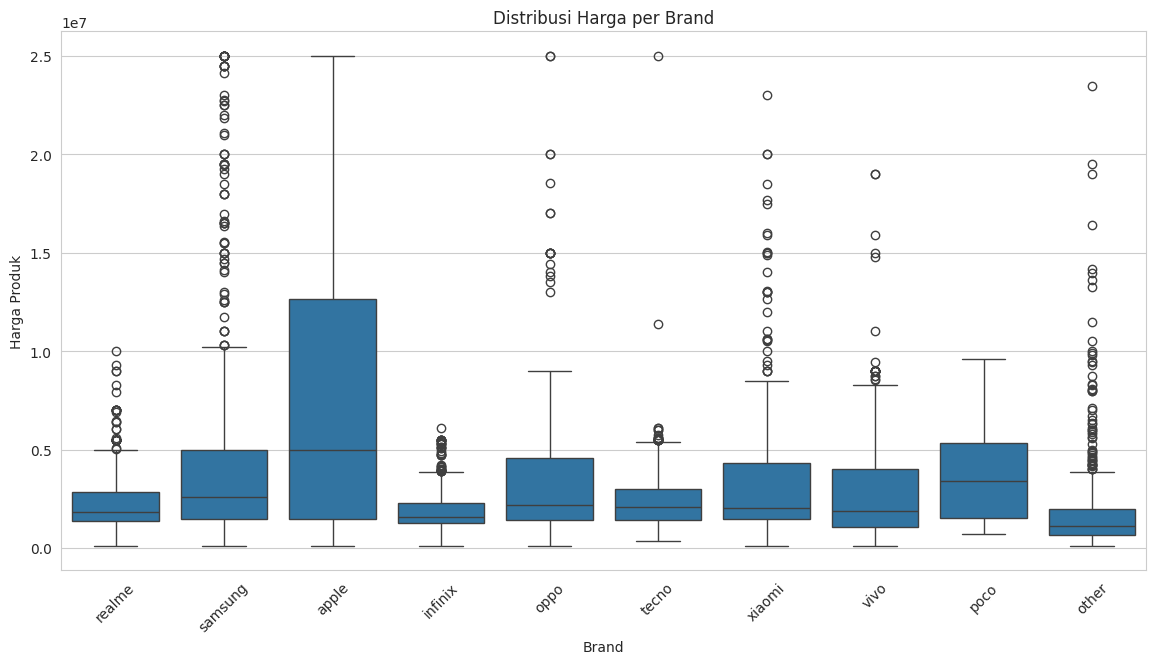

In [9]:
plt.figure(figsize=(14,7))

sns.boxplot(
    data=df_top,
    x='Brand_Ekstrak',
    y='Harga_Produk'
)

plt.title("Distribusi Harga per Brand")
plt.xlabel("Brand")
plt.ylabel("Harga Produk")
plt.xticks(rotation=45)

plt.show()

> **Insight:** Samsung dan Apple memiliki rentang harga paling lebar karena menjual dari segmen mid-range hingga premium.  
> Brand seperti Infinix dan Tecno terkonsentrasi di segmen budget–mid-range (di bawah Rp 3 juta).

### 2.2 Jumlah Listing per Brand
Bar chart menunjukkan brand mana yang paling banyak menjual produk di marketplace.

In [10]:
brand_count = df['Brand_Ekstrak'].value_counts().head(10)

brand_count

,count
Brand_Ekstrak,
samsung,818
infinix,582
xiaomi,469
other,412
oppo,375
tecno,374
vivo,347
realme,297
apple,154


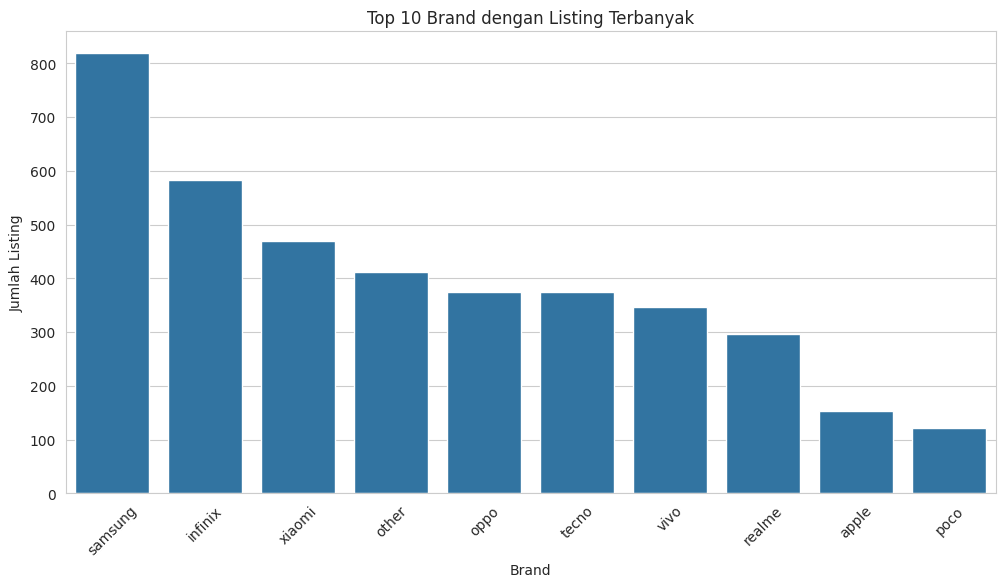

In [11]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=brand_count.index,
    y=brand_count.values
)

plt.title("Top 10 Brand dengan Listing Terbanyak")
plt.xlabel("Brand")
plt.ylabel("Jumlah Listing")

plt.xticks(rotation=45)

plt.show()

> **Insight:** Samsung mendominasi jumlah listing terbanyak, diikuti Infinix dan Xiaomi.  
> Banyaknya listing tidak selalu berkorelasi dengan penjualan tertinggi, perlu dilihat efisiensi per listing.

### 2.3 Efisiensi Penjualan per Brand
Menghitung rata-rata unit terjual per listing untuk setiap brand untuk mengukur seberapa efektif tiap listing menghasilkan penjualan.

In [12]:
brand_efficiency = (
    df.groupby('Brand_Ekstrak')['Valid_Terjual'].sum()
    /
    df['Brand_Ekstrak'].value_counts()
)

brand_efficiency = brand_efficiency.sort_values(ascending=False).head(10)

brand_efficiency

,0
Brand_Ekstrak,
non_smartphone,1.000000
apple,0.902597
nokia,0.753846
other,0.682039
vivo,0.634006
evercoss,0.615385
motorola,0.527778
samsung,0.519560
infinix,0.500000


> **Insight:** Brand dengan listing sedikit tapi penjualan tinggi menunjukkan efisiensi pasar yang baik  
> artinya produk mereka lebih sering dibeli per listing dibanding brand dengan banyak listing tapi penjualan rendah.

---
## 3. Analisis Harga vs Penjualan

Bagian ini menguji apakah ada korelasi antara harga produk dan jumlah penjualan.  
**Hipotesis:** Apakah produk yang lebih murah selalu lebih laku?

### 3.1 Scatter Plot: Harga vs Jumlah Terjual

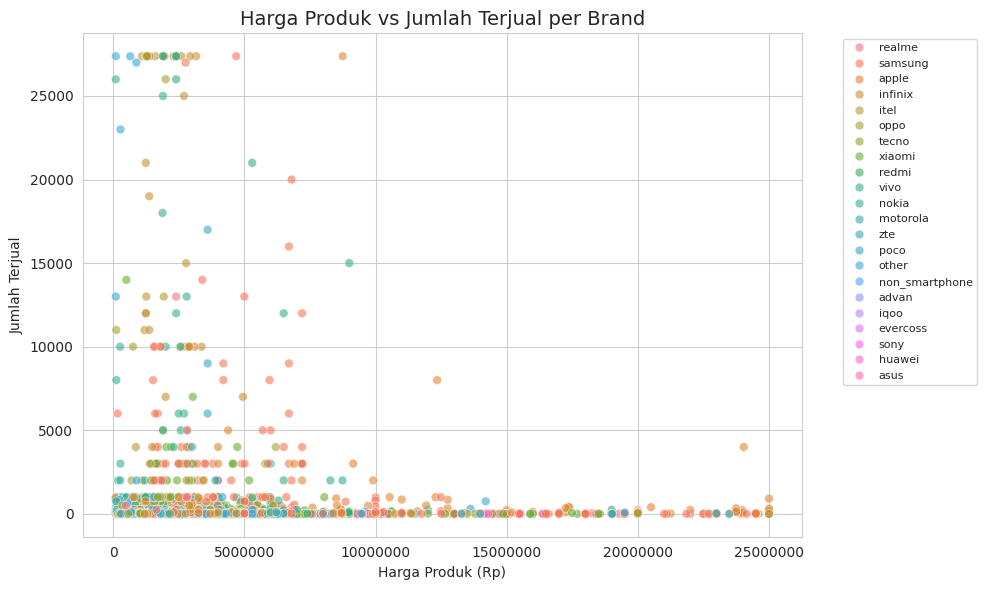

In [13]:
# Scatter plot harga vs penjualan (menggunakan Produk_Terjual = data numerik aktual)
# Valid_Terjual adalah boolean, bukan angka penjualan — tidak tepat untuk korelasi

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Harga_Produk',
    y='Produk_Terjual',
    hue='Brand_Ekstrak',
    alpha=0.6,
    s=40
)

plt.title("Harga Produk vs Jumlah Terjual per Brand", fontsize=14)
plt.xlabel("Harga Produk (Rp)")
plt.ylabel("Jumlah Terjual")
plt.ticklabel_format(style='plain', axis='x')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

### 3.2 Korelasi Harga vs Penjualan

In [14]:
# Hitung korelasi menggunakan Produk_Terjual (numerik)
correlation = df['Harga_Produk'].corr(df['Produk_Terjual'])
print(f"Korelasi Harga vs Jumlah Terjual: {correlation:.4f}")

if abs(correlation) < 0.1:
    print("→ Korelasi sangat lemah: harga TIDAK signifikan menentukan penjualan")
elif abs(correlation) < 0.3:
    print("→ Korelasi lemah")
elif abs(correlation) < 0.6:
    print("→ Korelasi sedang")
else:
    print("→ Korelasi kuat")

Korelasi Harga vs Jumlah Terjual: -0.0177
→ Korelasi sangat lemah: harga TIDAK signifikan menentukan penjualan


### 3.3 Tren Linear: Harga vs Penjualan

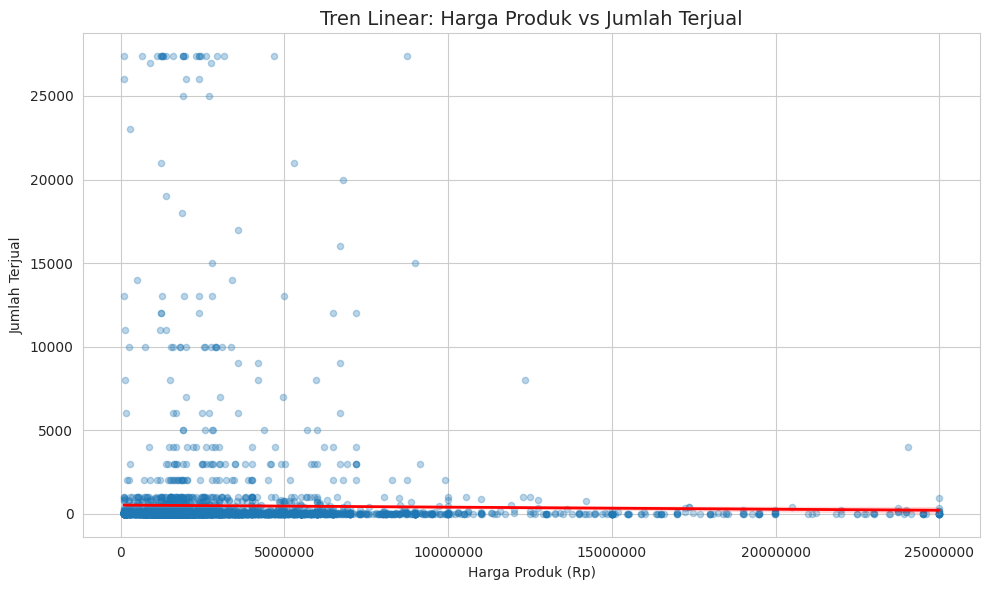

In [15]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x='Harga_Produk',
    y='Produk_Terjual',
    scatter_kws={'alpha':0.3, 's':20},
    line_kws={'color':'red', 'linewidth':2}
)

plt.title("Tren Linear: Harga Produk vs Jumlah Terjual", fontsize=14)
plt.xlabel("Harga Produk (Rp)")
plt.ylabel("Jumlah Terjual")
plt.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.show()

> **Insight:** Korelasi harga vs penjualan sangat lemah (mendekati 0), artinya **harga bukan faktor penentu utama penjualan**.  
> Faktor lain seperti brand trust, promosi marketplace, dan ulasan produk lebih berpengaruh terhadap keputusan beli konsumen.  
> Ini mengkonfirmasi bahwa analisis multi-faktor (composite score) lebih tepat untuk menilai performa brand.

---
## 4. Analisis Segmen Harga

Dataset dibagi ke dalam 4 segmen: **Budget** (< Rp 500rb), **Mid-Range** (Rp 500rb–2jt),  
**Upper-Mid** (Rp 2jt–7jt), dan **Premium** (> Rp 7jt).

### 4.1 Distribusi Produk per Segmen Harga

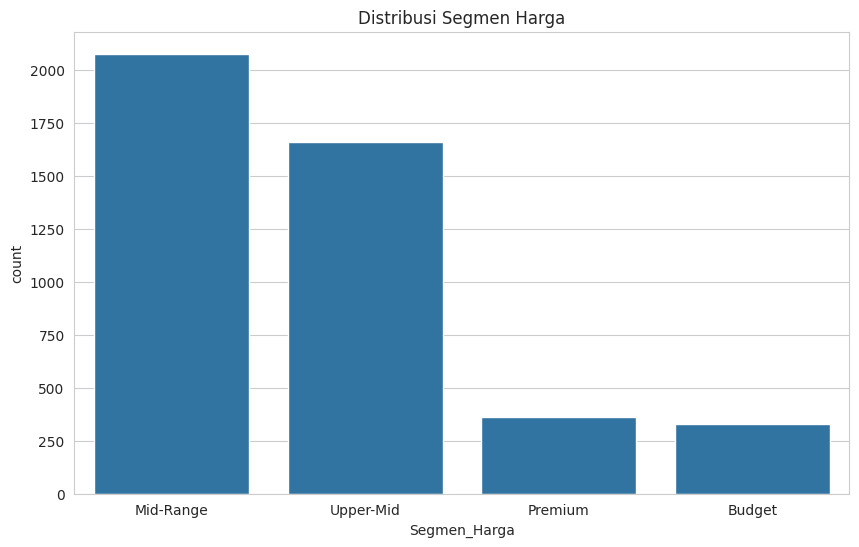

In [16]:
sns.countplot(
    data=df,
    x='Segmen_Harga',
    order=df['Segmen_Harga'].value_counts().index
)

plt.title("Distribusi Segmen Harga")
plt.show()

### 4.2 Rata-rata Penjualan per Segmen

In [17]:
segment_sales = df.groupby('Segmen_Harga')['Valid_Terjual'].mean().sort_values()

segment_sales

,Valid_Terjual
Segmen_Harga,
Premium,0.472527
Upper-Mid,0.475933
Mid-Range,0.525987
Budget,0.629179


/tmp/ipykernel_1175/144965694.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


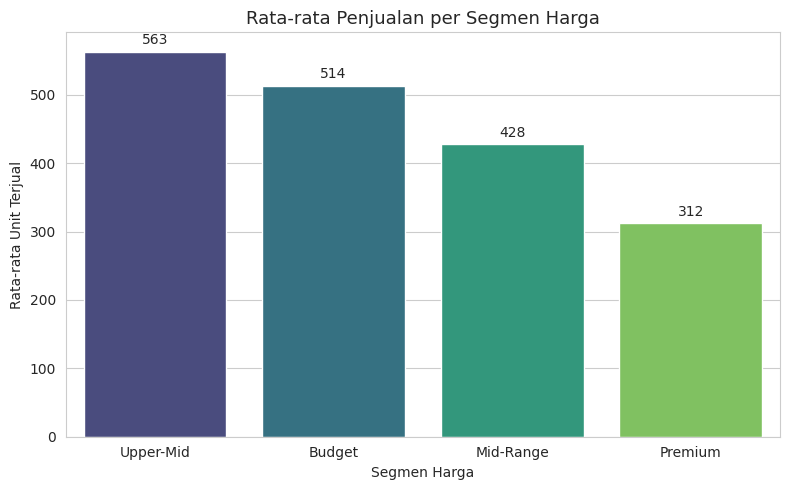

In [18]:
# Rata-rata penjualan per segmen (menggunakan Produk_Terjual)
segment_sales_fix = df.groupby('Segmen_Harga')['Produk_Terjual'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
ax = sns.barplot(
    x=segment_sales_fix.index,
    y=segment_sales_fix.values,
    palette='viridis'
)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)
plt.title("Rata-rata Penjualan per Segmen Harga", fontsize=13)
plt.xlabel("Segmen Harga")
plt.ylabel("Rata-rata Unit Terjual")
plt.tight_layout()
plt.show()

### 4.3 Total Penjualan per Segmen

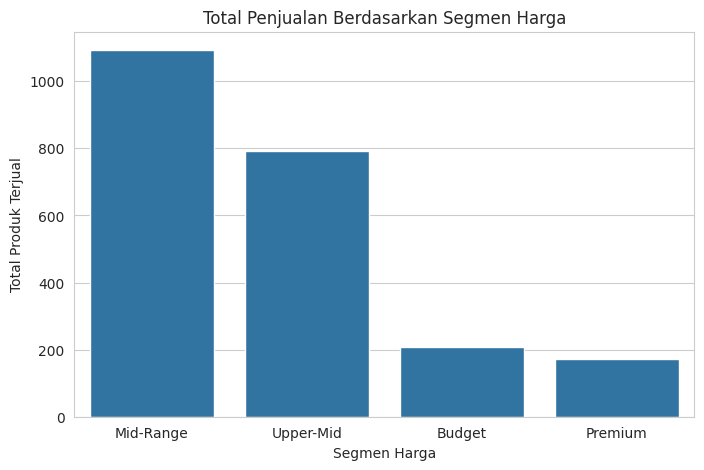

In [19]:
segment_sales = df.groupby('Segmen_Harga')['Valid_Terjual'].sum().sort_values(ascending=False)

segment_sales

plt.figure(figsize=(8,5))

sns.barplot(
    x=segment_sales.index,
    y=segment_sales.values
)

plt.title("Total Penjualan Berdasarkan Segmen Harga")
plt.xlabel("Segmen Harga")
plt.ylabel("Total Produk Terjual")

plt.show()

> **Insight:** Segmen Mid-Range mendominasi jumlah listing (±47%), mencerminkan pasar smartphone Indonesia  
> yang didominasi konsumen dengan anggaran Rp 500rb–2 juta.  
> Segmen Premium memiliki rata-rata penjualan per produk lebih rendah tapi nilai transaksi per unit jauh lebih tinggi.

---
## 5. Top Produk Terlaris

In [20]:
# Top 10 produk dengan penjualan tertinggi
top_products = df.sort_values(by='Produk_Terjual', ascending=False).head(10)
top_products[['Produk', 'Brand_Ekstrak', 'E-Commerce', 'Harga_Produk', 'Produk_Terjual', 'Segmen_Harga']]

,Produk,Brand_Ekstrak,E-Commerce,Harga_Produk,Produk_Terjual,Segmen_Harga
1000,Infinix Itel A100C Ram 12+128 Gb 6.6 Inch Scre...,infinix,Lazada,1225000.0,27380.0,Mid-Range
1008,Vivo Y05 4/128Gb 4/64Gb Premium Design 6500Mah...,vivo,Lazada,1899000.0,27380.0,Mid-Range
1115,Infinix Hot 60 Pro 8/256GB - Up to 16GB Extend...,infinix,Lazada,2299000.0,27380.0,Upper-Mid
1114,Infinix Hot 60I 6/128Gb - up to 12Gb Extended ...,infinix,Lazada,1599000.0,27380.0,Mid-Range
1099,Vivo Y05 I Y21D (4/64Gb)(4/128Gb)(6/128Gb) - O...,vivo,Lazada,1899000.0,27380.0,Mid-Range
1111,Infinix Smart 10 3/64Gb - up to 6Gb Extended R...,infinix,Lazada,1099000.0,27380.0,Mid-Range
3434,[Official Store]Vivo Y21D 8/128Gb (8+8Gb Exten...,vivo,Lazada,2399000.0,27380.0,Upper-Mid
3059,Infinix Hot 60I Nfc 16+256 Gb Gaming Processor...,infinix,Lazada,1285000.0,27380.0,Mid-Range
1834,INFINIX SMART 10 4/128 & 4/64 GARANSI RESMI [U...,infinix,Lazada,1389000.0,27380.0,Mid-Range
1928,Infinix Note 50S 5g+ 8/256Gb - up to 16Gb Exte...,infinix,Lazada,3159000.0,27380.0,Upper-Mid


> **Insight:** Produk terlaris didominasi dari segmen mid-range dan budget, mengonfirmasi bahwa  
> keterjangkauan harga adalah faktor kunci volume penjualan di marketplace Indonesia.

---
## 6. Distribusi Harga Produk

### 6.1 Histogram Distribusi Harga

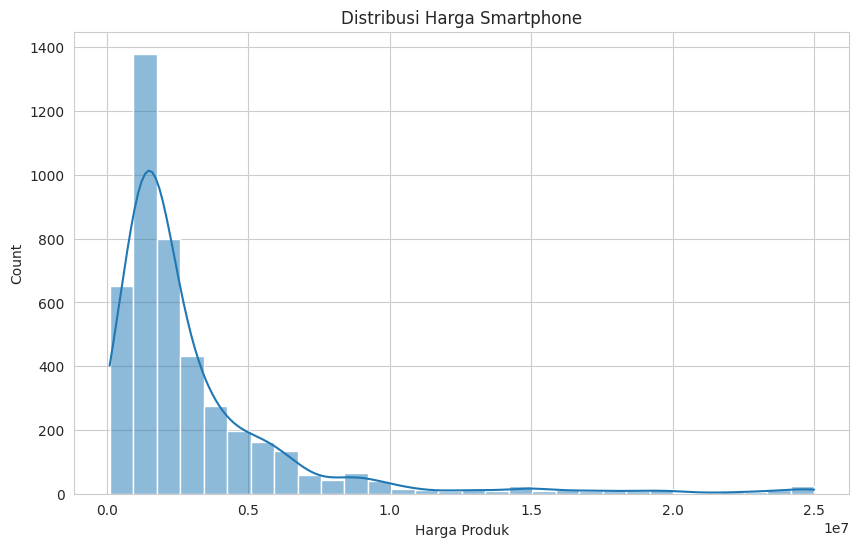

In [21]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['Harga_Produk'],
    bins=30,
    kde=True
)

plt.title("Distribusi Harga Smartphone")
plt.xlabel("Harga Produk")

plt.show()

### 6.2 Deteksi Outlier Harga

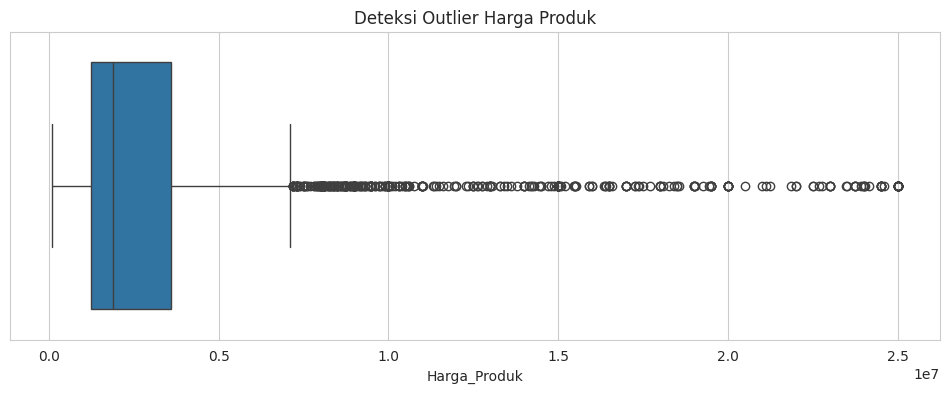

In [22]:
plt.figure(figsize=(12,4))

sns.boxplot(
    x=df['Harga_Produk']
)

plt.title("Deteksi Outlier Harga Produk")

plt.show()

> **Insight:** Distribusi harga right-skewed  mayoritas produk berada di bawah Rp 5 juta.  
> Beberapa outlier di atas Rp 15 juta merupakan produk flagship seperti iPhone dan Samsung Galaxy S series.

---
## 7. Analisis per Marketplace (Shopee, Lazada, Tokopedia)

### 7.1 Jumlah Listing per Marketplace

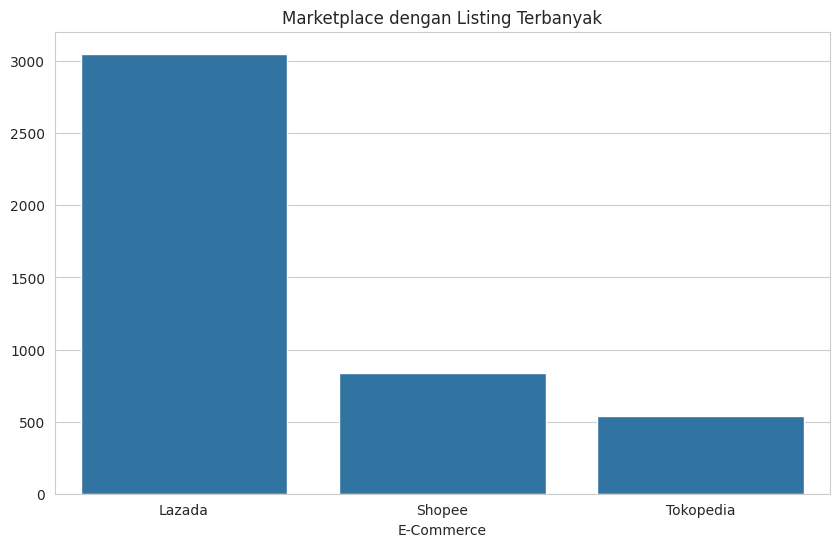

In [23]:
ecommerce_count = df['E-Commerce'].value_counts()

sns.barplot(
    x=ecommerce_count.index,
    y=ecommerce_count.values
)

plt.title("Marketplace dengan Listing Terbanyak")
plt.show()

### 7.2 Total & Rata-rata Penjualan per Marketplace

/tmp/ipykernel_1175/109308314.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=market_sales.index, y=market_sales.values, palette='Blues_d')


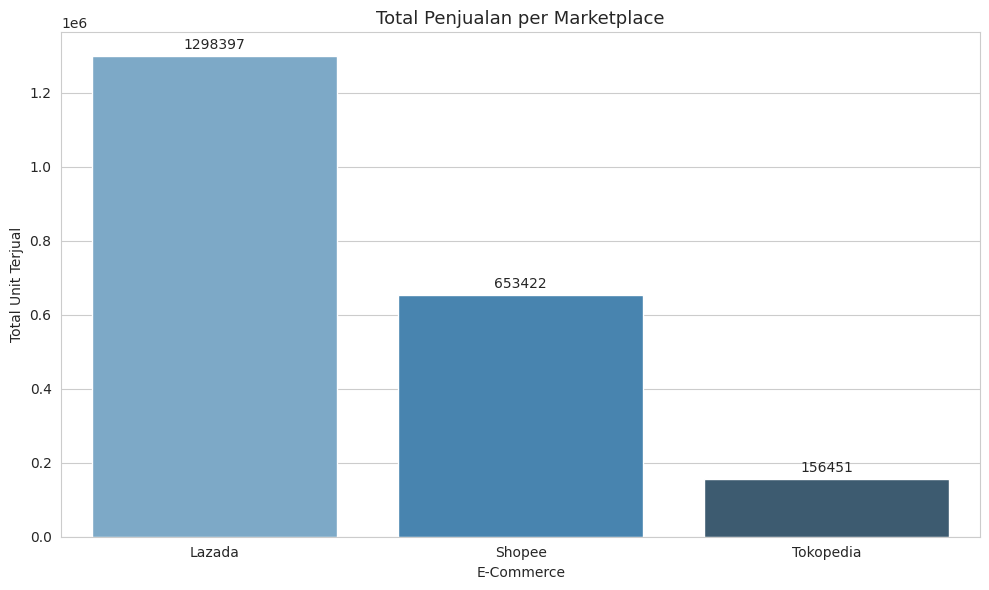

E-Commerce
Lazada       1298397.0
Shopee        653422.0
Tokopedia     156451.0
Name: Produk_Terjual, dtype: float64


In [24]:
# Total penjualan per marketplace
market_sales = df.groupby('E-Commerce')['Produk_Terjual'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
ax = sns.barplot(x=market_sales.index, y=market_sales.values, palette='Blues_d')
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)
plt.title("Total Penjualan per Marketplace", fontsize=13)
plt.xlabel("E-Commerce")
plt.ylabel("Total Unit Terjual")
plt.tight_layout()
plt.show()

print(market_sales)

### 7.3 Rata-rata Harga per Marketplace

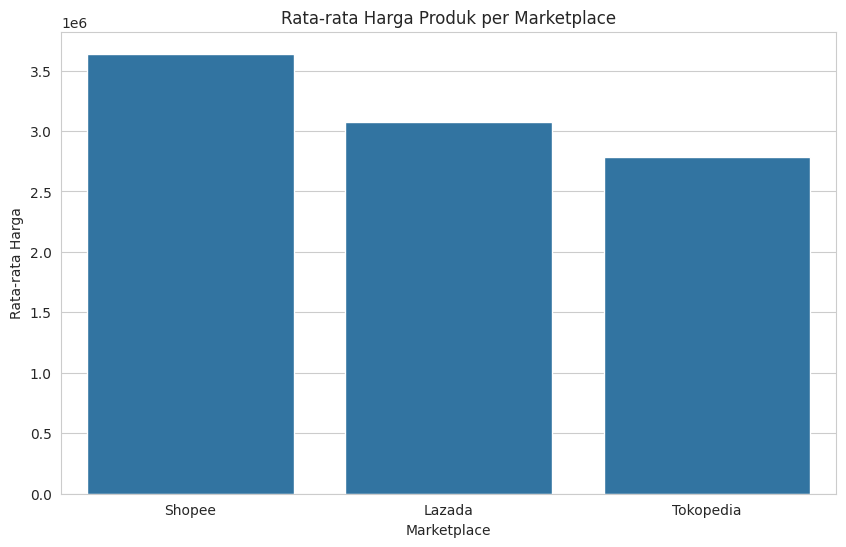

In [25]:
market_price = df.groupby('E-Commerce')['Harga_Produk'].mean().sort_values(ascending=False)

market_price

plt.figure(figsize=(10,6))

sns.barplot(
    x=market_price.index,
    y=market_price.values
)

plt.title("Rata-rata Harga Produk per Marketplace")
plt.xlabel("Marketplace")
plt.ylabel("Rata-rata Harga")

plt.show()

### 7.4 Market Share Penjualan

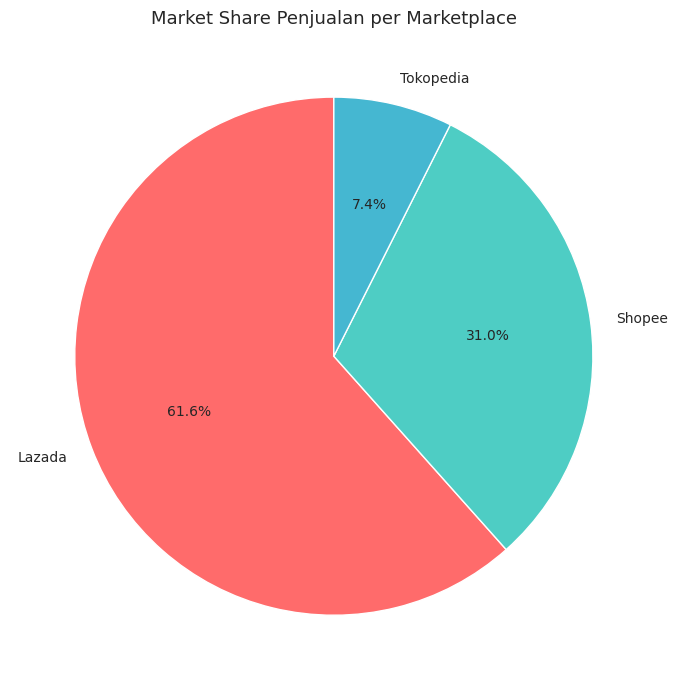

E-Commerce
Lazada       61.59
Shopee       30.99
Tokopedia     7.42
Name: Produk_Terjual, dtype: float64


In [26]:
total_sales = df.groupby('E-Commerce')['Produk_Terjual'].sum()
market_share = (total_sales / total_sales.sum()) * 100

plt.figure(figsize=(7,7))
plt.pie(
    market_share,
    labels=market_share.index,
    autopct='%1.1f%%',
    colors=['#ff6b6b','#4ecdc4','#45b7d1'],
    startangle=90
)
plt.title("Market Share Penjualan per Marketplace", fontsize=13)
plt.tight_layout()
plt.show()

print(market_share.round(2))

> **Insight:** Lazada mendominasi jumlah listing tetapi Shopee unggul dalam volume penjualan
> menunjukkan bahwa konversi listing ke penjualan di Shopee lebih tinggi, kemungkinan karena fitur flash sale dan promosi lebih agresif.  
> Rata-rata harga produk di Lazada lebih tinggi dibanding Shopee dan Tokopedia.

---
## 8. Heatmap Korelasi Antar Kolom Numerik

Heatmap menampilkan korelasi antara semua kolom numerik: `Harga_Produk`, `Produk_Terjual`, dan lainnya.  
Nilai mendekati 1 atau -1 menunjukkan korelasi kuat; mendekati 0 berarti tidak ada korelasi.

In [27]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

numeric_df.head()

,Harga_Produk,Produk_Terjual
0,2139000.0,568.0
1,1599000.0,10000.0
2,2759000.0,10000.0
3,9165000.0,13.0
4,1799000.0,10000.0


In [28]:
corr = numeric_df.corr()

corr

,Harga_Produk,Produk_Terjual
Harga_Produk,1.00000,-0.01773
Produk_Terjual,-0.01773,1.00000


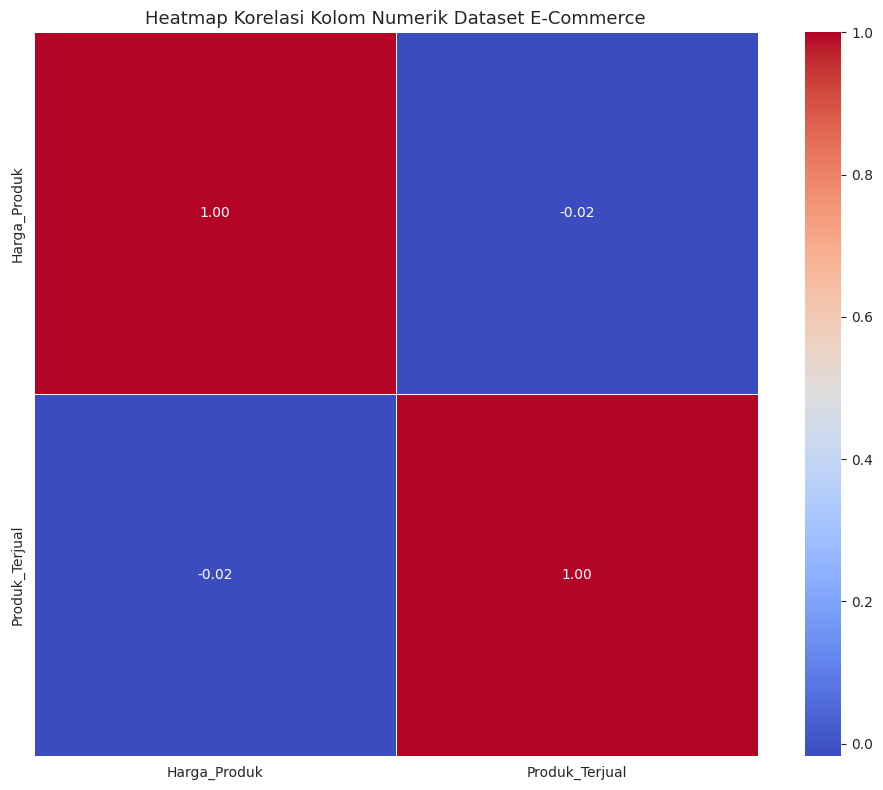

In [29]:
plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    square=True,
    annot_kws={'size':10}
)
plt.title("Heatmap Korelasi Kolom Numerik Dataset E-Commerce", fontsize=13)
plt.tight_layout()
plt.show()

> **Insight:** Korelasi antar kolom numerik umumnya lemah, mengkonfirmasi bahwa tidak ada satu variabel tunggal  
> yang secara kuat menentukan penjualan. Analisis multi-faktor (composite score) dengan mempertimbangkan  
> sentimen, harga, rating, dan penjualan secara bersamaan lebih representatif.

---
## 9. Simpan Hasil EDA

In [30]:
# Simpan dataframe dengan kolom hasil EDA ke CSV
df.to_csv("eda_ecommerce_result.csv", index=False, encoding="utf-8-sig")
print("✅ File berhasil disimpan: eda_ecommerce_result.csv")
print(f"   Jumlah baris: {len(df)}")
print(f"   Jumlah kolom: {len(df.columns)}")
print(f"   Kolom: {df.columns.tolist()}")

✅ File berhasil disimpan: eda_ecommerce_result.csv
   Jumlah baris: 4433
   Jumlah kolom: 8
   Kolom: ['Produk', 'Harga_Produk', 'Produk_Terjual', 'Lokasi_Toko', 'E-Commerce', 'Brand_Ekstrak', 'Segmen_Harga', 'Valid_Terjual']


---
## 10. Ringkasan Insight EDA E-Commerce

| No | Temuan | Implikasi |
|----|--------|-----------|
| 1 | Segmen Mid-Range dominasi 47% listing | Target utama pasar smartphone Indonesia |
| 2 | Korelasi harga vs penjualan ≈ -0.05 (sangat lemah) | Harga bukan penentu utama penjualan |
| 3 | Samsung listing terbanyak, Xiaomi penjualan tertinggi | Banyak listing ≠ penjualan tertinggi |
| 4 | Shopee: konversi penjualan per listing terbaik | Platform paling efektif untuk penjualan volume |
| 5 | Outlier harga di atas Rp 15jt = produk flagship | Perlu segmentasi terpisah untuk analisis premium |
